In [1]:
from pathlib import Path
import xarray as xr
import numpy as np

folder = Path("/mnt/ceph/proj/WEKEO/S5P_PCA_V0.1")
file = folder / "S5P-PCA-BD7_2021-08-01_v0.1.nc"


ds = xr.open_dataset(file)

for v in ds.data_vars:
    print(v, "    ", ds[v].dims)

print(ds.processing_flag.attrs)
# print(ds)

latitude      ('time', 'scanline', 'ground_pixel')
longitude      ('time', 'scanline', 'ground_pixel')
cloud_fraction      ('time', 'scanline', 'ground_pixel')
score_CO_1      ('time', 'scanline', 'ground_pixel')
diag_CO_1      ('time', 'scanline', 'ground_pixel')
score_CO_2      ('time', 'scanline', 'ground_pixel')
diag_CO_2      ('time', 'scanline', 'ground_pixel')
score_CO_3      ('time', 'scanline', 'ground_pixel')
diag_CO_3      ('time', 'scanline', 'ground_pixel')
score_CH4_2      ('time', 'scanline', 'ground_pixel')
diag_CH4_2      ('time', 'scanline', 'ground_pixel')
score_CH4_3      ('time', 'scanline', 'ground_pixel')
diag_CH4_3      ('time', 'scanline', 'ground_pixel')
score_Surf_1      ('time', 'scanline', 'ground_pixel')
diag_Surf_1      ('time', 'scanline', 'ground_pixel')
score_Surf_2      ('time', 'scanline', 'ground_pixel')
diag_Surf_2      ('time', 'scanline', 'ground_pixel')
score_Total_7      ('time', 'scanline', 'ground_pixel')
diag_Total_7      ('time', 'scanline'

In [2]:
from wekeo_s5p_pca_l3 import processor

ds = processor.preprocess(ds=ds, min_detection=1, fill_value=-9999)

print(ds)

/home/dom/.cache/rattler/cache/envs/wekeo_s5p_pca-7382357759430118190/envs/default/lib/python3.14/site-packages/xarray/core/duck_array_ops.py:264: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


<xarray.Dataset> Size: 1GB
Dimensions:          (time: 14, scanline: 4173, ground_pixel: 215)
Coordinates:
  * time             (time) datetime64[ns] 112B 2021-08-01T00:26:08 ... 2021-...
  * scanline         (scanline) int16 8kB 0 1 2 3 4 ... 4168 4169 4170 4171 4172
  * ground_pixel     (ground_pixel) int16 430B 0 1 2 3 4 ... 210 211 212 213 214
Data variables: (12/21)
    latitude         (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    longitude        (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    cloud_fraction   (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    score_CO_1       (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    diag_CO_1        (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    score_CO_2       (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    ...               ...
    score_Surf_2     (time, scanline, ground_pixel) float32 50MB nan nan ... nan
    diag_Surf_2      (time, scanl

In [ ]:
from wekeo_s5p_pca_l3 import processor

ds = processor.accumulate_to_grid(ds, width=3272)

print(ds)

/home/dom/Project/dev/wekeo_s5p_pca_l3/wekeo_s5p_pca_l3/processor.py:126: RuntimeWarning: invalid value encountered in cast
  lat_idx = np.uint32(
/home/dom/Project/dev/wekeo_s5p_pca_l3/wekeo_s5p_pca_l3/processor.py:130: RuntimeWarning: invalid value encountered in cast
  lon_idx = np.uint32(


<xarray.Dataset> Size: 17MB
Dimensions:               (latitude: 360, longitude: 720)
Coordinates:
  * latitude              (latitude) float64 3kB -90.0 -89.5 -89.0 ... 89.5 90.0
  * longitude             (longitude) float64 6kB -180.0 -179.5 ... 179.0 179.5
Data variables: (12/16)
    cloud_fraction_mean   (latitude, longitude) float32 1MB nan nan ... nan nan
    cloud_fraction_count  (latitude, longitude) int32 1MB -1 -1 -1 ... -1 -1 -1
    score_CO_1_mean       (latitude, longitude) float32 1MB nan nan ... nan nan
    score_CO_1_count      (latitude, longitude) int32 1MB -1 -1 -1 ... -1 -1 -1
    score_CO_2_mean       (latitude, longitude) float32 1MB nan nan ... nan nan
    score_CO_2_count      (latitude, longitude) int32 1MB -1 -1 -1 ... -1 -1 -1
    ...                    ...
    diag_CO_2_mean        (latitude, longitude) float32 1MB nan nan ... nan nan
    diag_CO_2_count       (latitude, longitude) int32 1MB -1 -1 -1 ... -1 -1 -1
    diag_CO_3_mean        (latitude, longitud

Figure saved to: plots/S5P_PCA_L3_20210801_score_CO_1_mean.png


(<Figure size 1600x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'Score Co 1 Mean\n(801 non-zero pixels, 801 valid pixels)'}>)

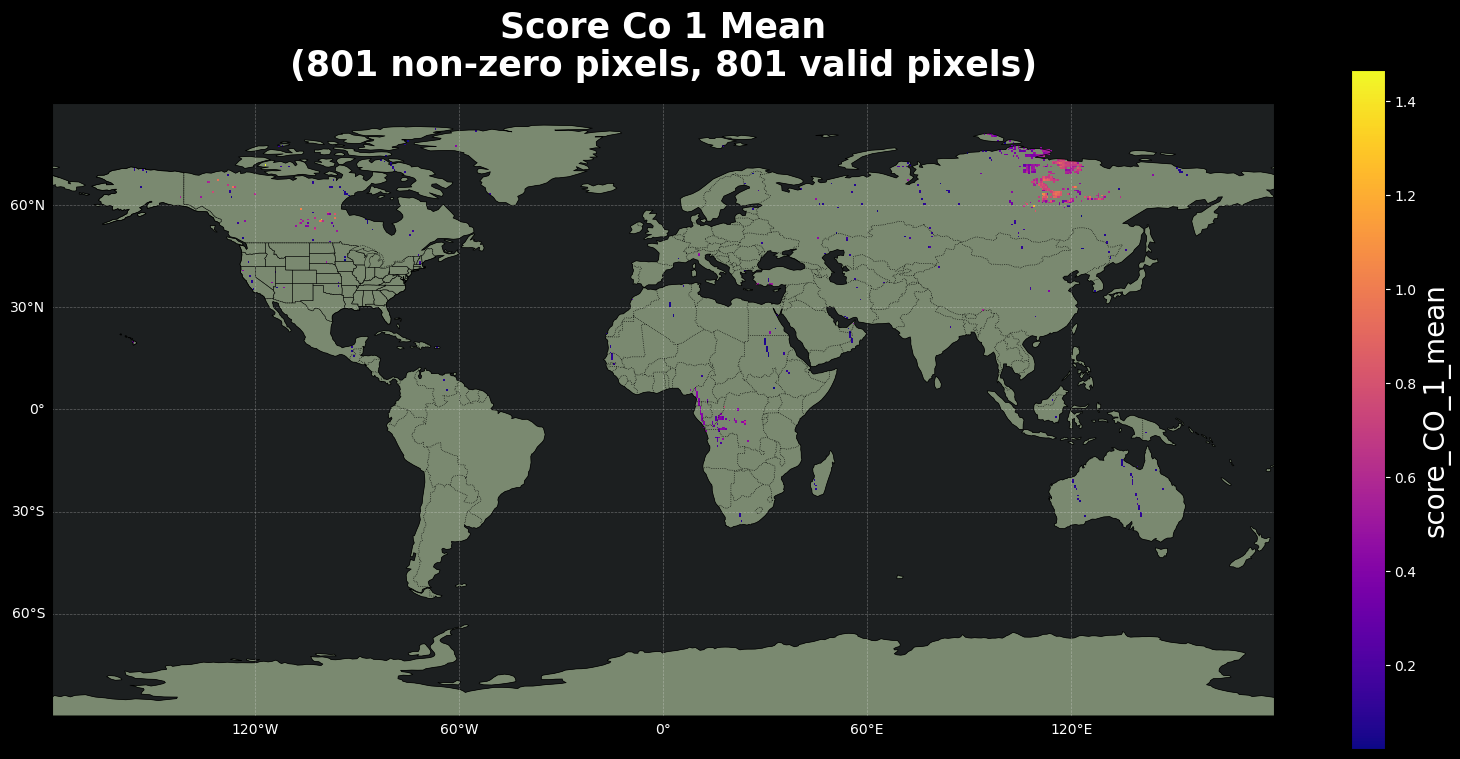

In [4]:
from wekeo_s5p_pca_l3.plot_L3_s5p_pca import plot_L3_s5p_pca
from wekeo_s5p_pca_l3 import processor

ds = processor.postprocess(ds)

plot_L3_s5p_pca(
    ds, 
    variable='score_CO_1_mean',
    save_fig_dir='./plots'
)


In [ ]:
for v in ds.data_vars:
    print(v, ds[v].dims)